# Geostationary Imager Validation: GOES-19 ABI

A geostationary imager sees the same disk of the Earth continuously. The Advanced Baseline Imager (ABI) on [GOES-19](https://www.goes-r.gov/), the operational GOES-East satellite at 75.2 deg west, scans this full disk every 10 minutes. Its products are retrieved only where the satellite is high enough above the horizon: each declares the range of local zenith angles (the angle between the local vertical and the direction to the satellite) where it is retrieved and where it is of good quality. In TAT-C, an instrument observes points within its field of regard, the cone around nadir whose half angle is the maximum angle from nadir; a maximum local zenith angle (or a minimum elevation angle, 90 deg minus it) corresponds to a field of regard (`compute_field_of_regard`). This notebook compares these with GOES-19's full-disk products, and asks:

1. **Earth disk.** Does TAT-C observe the full disk that ABI images, and does its viewing geometry (the satellite's elevation angle) match ABI's?
2. **Product coverage.** Do fields of regard computed from the products' maximum local zenith angles reproduce the regions where the products are of good quality?

## Reference Data

GOES-19 ABI full-disk products for 3 October 2026, 12:00 UTC, are downloaded from the [NOAA Open Data Dissemination](https://registry.opendata.aws/noaa-goes/) archive on Amazon Web Services (anonymous access): the clear sky mask (ACM, 2 km pixels), whose fill values mark pixels off the Earth's disk; the sea surface temperature (SST, 2 km, hourly); and the land surface temperature (LST, 10 km, hourly). Pixel locations follow from ABI's fixed grid (scan angles from a nominal satellite position on the equator). The files (about 50 MB) are cached in a local `data/goes` directory.

GOES-19 is modeled with a two-line element set (TLE) from [CelesTrak](https://celestrak.org/) with an epoch of 4 October 2026.

In [1]:
import concurrent.futures
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from skyfield.framelib import itrs

from tatc.analysis import collect_observations
from tatc.constants import timescale
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Point, Satellite
from tatc.utils import compute_field_of_regard

DATA_DIR = Path("data") / "goes"
DATA_DIR.mkdir(parents=True, exist_ok=True)
BUCKET = "https://noaa-goes19.s3.amazonaws.com/"
TIME = datetime(2026, 10, 3, 12, tzinfo=timezone.utc)
TLE = [
    "1 60133U 24119A   26277.37537957 -.00000263  00000+0  00000+0 0  9990",
    "2 60133   0.0344  24.5665 0000927 249.5134 158.9494  1.00270254  8054",
]


def download(product):
    """Download the first full-disk file of a product starting in the hour of TIME."""
    prefix = f"{product}/{TIME:%Y}/{TIME.timetuple().tm_yday:03d}/{TIME:%H}/"
    root = ET.fromstring(requests.get(BUCKET, params={"list-type": "2", "prefix": prefix}, timeout=120).content)
    key = root.find("{http://s3.amazonaws.com/doc/2006-03-01/}Contents/{http://s3.amazonaws.com/doc/2006-03-01/}Key").text
    path = DATA_DIR / key.split("/")[-1]
    if not path.exists():
        response = requests.get(BUCKET + key, timeout=600)
        response.raise_for_status()
        path.write_bytes(response.content)
    return path


paths = {product: sorted(DATA_DIR.glob(f"OR_{product}-M6_G19_s{TIME:%Y}{TIME.timetuple().tm_yday:03d}{TIME:%H}*.nc")) for product in ["ABI-L2-ACMF", "ABI-L2-SSTF", "ABI-L2-LSTF"]}
paths = {product: found[0] if found else download(product) for product, found in paths.items()}


def fixed_grid(ds):
    """Geodetic latitude and longitude (deg) of ABI fixed grid pixels (NaN off the Earth)."""
    projection = ds.goes_imager_projection.attrs
    r_eq, r_pol = projection["semi_major_axis"], projection["semi_minor_axis"]
    h = projection["perspective_point_height"] + r_eq
    lon_0 = np.radians(projection["longitude_of_projection_origin"])
    x, y = np.meshgrid(ds.x.values, ds.y.values)
    a = np.sin(x) ** 2 + np.cos(x) ** 2 * (np.cos(y) ** 2 + (r_eq / r_pol) ** 2 * np.sin(y) ** 2)
    b = -2 * h * np.cos(x) * np.cos(y)
    c = h**2 - r_eq**2
    discriminant = b**2 - 4 * a * c
    with np.errstate(invalid="ignore"):
        r_s = (-b - np.sqrt(discriminant)) / (2 * a)
        s_x, s_y, s_z = r_s * np.cos(x) * np.cos(y), -r_s * np.sin(x), r_s * np.cos(x) * np.sin(y)
        latitude = np.degrees(np.arctan((r_eq / r_pol) ** 2 * s_z / np.sqrt((h - s_x) ** 2 + s_y**2)))
        longitude = np.degrees(lon_0 - np.arctan(s_y / (h - s_x)))
    return latitude, longitude


goes19 = GeneralPerturbationsOrbit.from_tle(TLE)
satellite_itrs = np.array(goes19.elements[0].to_skyfield().at(timescale.from_datetime(TIME)).frame_xyz(itrs).m)


def elevation(latitude, longitude):
    """Elevation angle (deg) of GOES-19 (from its TLE) above the local (geodetic) horizon."""
    lat, lon = np.radians(latitude), np.radians(longitude)
    a, f = 6378137.0, 1 / 298.257223563
    e2 = f * (2 - f)
    n = a / np.sqrt(1 - e2 * np.sin(lat) ** 2)
    position = np.stack([n * np.cos(lat) * np.cos(lon), n * np.cos(lat) * np.sin(lon), n * (1 - e2) * np.sin(lat)], axis=-1)
    up = np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)
    line_of_sight = satellite_itrs - position
    return np.degrees(np.arcsin(np.sum(up * line_of_sight, axis=-1) / np.linalg.norm(line_of_sight, axis=-1)))


BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})
products = {product: xr.open_dataset(path) for product, path in paths.items()}
pd.DataFrame(
    {
        product.replace("ABI-L2-", "").replace("F", ""): {
            "pixels": f"{ds.sizes['x']} x {ds.sizes['y']}",
            "retrieval local zenith angles (deg)": "0 to {:g}".format(float(ds.retrieval_local_zenith_angle_bounds[1])),
            "good-quality local zenith angles (deg)": "0 to {:g}".format(float(ds.quantitative_local_zenith_angle_bounds[1])),
        }
        for product, ds in products.items()
    }
).T

,pixels,retrieval local zenith angles (deg),good-quality local zenith angles (deg)
ACM,5424 x 5424,0 to 90,0 to 70
SST,5424 x 5424,0 to 90,0 to 67
LST,1086 x 1086,0 to 85,0 to 55


## Test 1: Earth Disk

Every 8th pixel of the clear sky mask's 2 km grid (in both directions) is located on the Earth (or found to be off the disk) from ABI's fixed grid. A pixel is on the imaged disk if its clear sky mask is defined. GOES-19's elevation angle at each pixel is computed from the TLE, and TAT-C's observations are evaluated for a random sample of 2,000 pixels (`collect_observations` over 10 minutes) with an instrument whose field of regard (17.4 deg) spans the Earth's disk from geostationary altitude.

In [2]:
acm = products["ABI-L2-ACMF"].isel(x=slice(0, None, 8), y=slice(0, None, 8))
latitude, longitude = fixed_grid(acm)
on_grid = np.isfinite(latitude)
imaged = np.isfinite(acm.ACM.values)
grid_elevation = np.where(on_grid, elevation(np.nan_to_num(latitude), np.nan_to_num(longitude)), np.nan)
abi = Instrument(name="ABI", field_of_regard=17.4)
satellite = Satellite(name="GOES-19", orbit=goes19, instruments=[abi])
rng = np.random.default_rng(1)
sample = rng.choice(np.flatnonzero(on_grid), 2000, replace=False)


def observed(index):
    """TAT-C's observation of a pixel, and the satellite's elevation angle."""
    point = Point(id=0, latitude=float(latitude.flat[index]), longitude=float(longitude.flat[index]))
    obs = collect_observations(point, satellite, TIME, TIME + timedelta(minutes=10))
    return {"index": index, "observed": not obs.empty, "sat_alt": obs.sat_alt.iloc[0] if not obs.empty else np.nan}


with concurrent.futures.ThreadPoolExecutor(8) as pool:
    sample1 = pd.DataFrame(list(pool.map(observed, sample)))
sample1["imaged"] = imaged.ravel()[sample1["index"].to_numpy()]
sample1["elevation"] = grid_elevation.ravel()[sample1["index"].to_numpy()]
pd.Series(
    {
        "grid pixels on the Earth": int(on_grid.sum()),
        "pixels on the Earth imaged (%)": 100 * imaged[on_grid].mean(),
        "imaged pixels off the Earth": int((imaged & ~on_grid).sum()),
        "minimum elevation angle of imaged pixels (deg)": float(np.nanmin(grid_elevation[imaged])),
        "sampled pixels: imaged (%)": 100 * sample1.imaged.mean(),
        "sampled pixels: observed by TAT-C (%)": 100 * sample1.observed.mean(),
        "sampled imaged pixels observed by TAT-C (%)": 100 * sample1.observed[sample1.imaged].mean(),
        "TAT-C sat_alt minus elevation, max |x| (deg)": float((sample1.sat_alt - sample1.elevation).abs().max()),
    }
).round(4)

grid pixels on the Earth                          360070.0000
pixels on the Earth imaged (%)                        99.9997
imaged pixels off the Earth                            0.0000
minimum elevation angle of imaged pixels (deg)         0.0055
sampled pixels: imaged (%)                           100.0000
sampled pixels: observed by TAT-C (%)                100.0000
sampled imaged pixels observed by TAT-C (%)          100.0000
TAT-C sat_alt minus elevation, max |x| (deg)           0.0004
dtype: float64

ABI images the whole Earth disk: all but one of the 360,070 sampled grid pixels on the Earth have a clear sky mask, none off the Earth do, and the imaged pixels extend to the limb (GOES-19 0.006 deg above the horizon). TAT-C, with a 17.4 deg field of regard, observes every sampled pixel, and the satellite elevation angle it reports (`sat_alt`) agrees with the elevation computed from the same orbit and ABI's pixel locations to within 0.0004 deg. A 17.4 deg field of regard thus spans the disk that ABI's full-disk scan images from geostationary altitude.

## Test 2: Product Coverage

The sea and land surface temperature products report a quality flag for each pixel (good, degraded, or worse, and no retrieval where they are not produced). The local zenith angle of each pixel (90 deg minus GOES-19's elevation angle) is compared with the product's declared bounds. TAT-C models each product with an instrument whose field of regard corresponds to its good-quality bound (`compute_field_of_regard` from geostationary altitude with a minimum elevation angle of 90 deg minus the bound), and its observations are evaluated for a random sample of 2,000 retrieved pixels of each product within 5 deg of the bound.

In [3]:
rows2, zenith_by_product = {}, {}
for product, quality_name in [("ABI-L2-SSTF", "SST"), ("ABI-L2-LSTF", "LST")]:
    ds = products[product]
    step = 4 if ds.sizes["x"] > 2000 else 1
    ds = ds.isel(x=slice(0, None, step), y=slice(0, None, step))
    lat, lon = fixed_grid(ds)
    valid = np.isfinite(lat)
    zenith = np.where(valid, 90 - elevation(np.nan_to_num(lat), np.nan_to_num(lon)), np.nan)
    retrieved = np.isfinite(ds[quality_name].values)
    good = retrieved & (ds.DQF.values == 0)
    good_bound = float(ds.quantitative_local_zenith_angle_bounds[1])
    retrieval_bound = float(ds.retrieval_local_zenith_angle_bounds[1])
    zenith_by_product[quality_name] = (zenith, retrieved, good, good_bound, retrieval_bound)
    field_of_regard = compute_field_of_regard(35786e3, 90 - good_bound)
    product_satellite = Satellite(name="GOES-19", orbit=goes19, instruments=[Instrument(name=quality_name, field_of_regard=field_of_regard)])
    near_bound = retrieved & (np.abs(zenith - good_bound) <= 5)
    picks = rng.choice(np.flatnonzero(near_bound), 2000, replace=False)

    def observed_with_bound(index, lat=lat, lon=lon, product_satellite=product_satellite):
        point = Point(id=0, latitude=float(lat.flat[index]), longitude=float(lon.flat[index]))
        return not collect_observations(point, product_satellite, TIME, TIME + timedelta(minutes=10)).empty

    with concurrent.futures.ThreadPoolExecutor(8) as pool:
        tatc = np.array(list(pool.map(observed_with_bound, picks)))
    picked_zenith, picked_good = zenith.flat[picks], good.flat[picks]
    rows2[quality_name] = {
        "declared bounds, good / retrieved (deg)": f"{good_bound:g} / {retrieval_bound:g}",
        "max local zenith angle, retrieved pixels (deg)": float(np.nanmax(zenith[retrieved])),
        "max local zenith angle, good-quality pixels (deg)": float(np.nanmax(zenith[good])),
        "retrieved pixels beyond the retrieval bound": int((retrieved & (zenith > retrieval_bound)).sum()),
        "good-quality pixels beyond the good bound (%)": 100 * (good & (zenith > good_bound)).sum() / good.sum(),
        "TAT-C field of regard (deg)": field_of_regard,
        "TAT-C: max local zenith angle observed (deg)": float(picked_zenith[tatc].max()),
        "TAT-C: min local zenith angle not observed (deg)": float(picked_zenith[~tatc].min()),
        "sampled good-quality pixels observed by TAT-C (%)": 100 * tatc[picked_good].mean(),
        "sampled pixels observed by TAT-C that are good quality (%)": 100 * picked_good[tatc].mean(),
        "sampled pixels not observed by TAT-C that are good quality (%)": 100 * picked_good[~tatc].mean(),
    }
pd.DataFrame(rows2).T.round(3)

,"declared bounds, good / retrieved (deg)","max local zenith angle, retrieved pixels (deg)","max local zenith angle, good-quality pixels (deg)",retrieved pixels beyond the retrieval bound,good-quality pixels beyond the good bound (%),TAT-C field of regard (deg),TAT-C: max local zenith angle observed (deg),TAT-C: min local zenith angle not observed (deg),sampled good-quality pixels observed by TAT-C (%),sampled pixels observed by TAT-C that are good quality (%),sampled pixels not observed by TAT-C that are good quality (%)
SST,67 / 90,89.656813,67.204013,0,0.133262,15.992926,67.243207,66.937867,99.492386,18.473139,0.106496
LST,55 / 85,88.042072,55.244306,407,0.428148,14.222342,55.267491,55.152246,99.593082,81.651376,0.499376


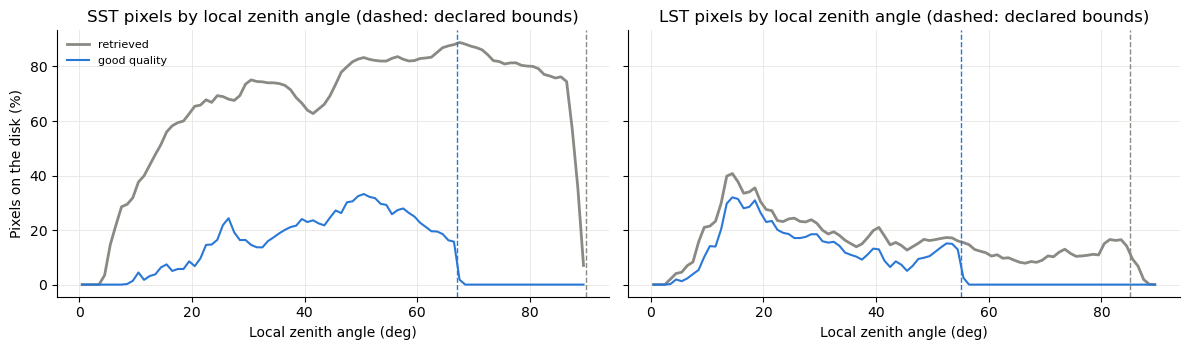

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
bins = np.arange(0, 91, 1)
for ax, (name, (zenith, retrieved, good, good_bound, retrieval_bound)) in zip(axes, zenith_by_product.items()):
    counts_retrieved = np.histogram(zenith[retrieved], bins)[0]
    counts_good = np.histogram(zenith[good], bins)[0]
    total = np.histogram(zenith[np.isfinite(zenith)], bins)[0]
    with np.errstate(invalid="ignore", divide="ignore"):
        ax.plot(bins[:-1] + 0.5, 100 * counts_retrieved / total, color=GRAY, lw=2, label="retrieved")
        ax.plot(bins[:-1] + 0.5, 100 * counts_good / total, color=BLUE, lw=1.5, label="good quality")
    ax.axvline(good_bound, color=BLUE, ls="--", lw=1)
    ax.axvline(retrieval_bound, color=GRAY, ls="--", lw=1)
    ax.set(xlabel="Local zenith angle (deg)", title=f"{name} pixels by local zenith angle (dashed: declared bounds)")
axes[0].set_ylabel("Pixels on the disk (%)")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Both products respect their declared bounds: the sea surface temperature is retrieved to a local zenith angle of 89.7 deg and is of good quality to 67.2 deg, and the land surface temperature is of good quality to 55.2 deg. A few good-quality pixels (0.13% and 0.43%) lie up to 0.2 deg beyond the bounds, probably from small differences in how the products compute the local zenith angle; the land surface temperature, on a 10 km grid, is also retrieved at 407 pixels up to 88 deg, beyond its 85 deg retrieval bound.

The fields of regard corresponding to the good-quality bounds (16.0 and 14.2 deg) reproduce them to within about 0.3 deg: TAT-C observes pixels up to local zenith angles of 67.2 and 55.3 deg and no pixels beyond 66.9 and 55.2 deg (the boundary varies slightly with latitude, as `compute_field_of_regard` assumes a spherical Earth while observations are evaluated on the ellipsoid). Within 5 deg of the bounds, TAT-C observes 99.5 to 99.6% of the good-quality pixels, and only 0.1 to 0.5% of the pixels it does not observe are of good quality.

## Summary

| Test | Result |
| --- | --- |
| 1. Earth disk | a 17.4 deg field of regard observes every pixel ABI images, to the limb; satellite elevation angles within 0.0004 deg |
| 2. Product coverage (`compute_field_of_regard`) | fields of regard from the products' maximum local zenith angles reproduce their good-quality regions to within about 0.3 deg (99.5% of good-quality pixels near the bounds observed) |

**Earth disk.** TAT-C's geostationary viewing geometry matches ABI's: a field of regard spanning the Earth's disk observes everything ABI images, and its satellite elevation angles match those from ABI's pixel locations.

**Product coverage.** A geostationary product's coverage is limited by a maximum local zenith angle, which TAT-C models with a field of regard computed for the corresponding minimum elevation angle; it reproduces the products' good-quality regions to within a few tenths of a degree of local zenith angle, the difference between a spherical and an ellipsoidal Earth near the bound. (TAT-C points have no minimum elevation angle of their own: elevation limits are set through the instrument's field of regard.)